#### Week 2: The Mean as a Statistical Model
PURPOSE
Continue to develop an understanding of what a statistical model is, and how it is fit to the data.  
Using the simple model of a mean, students will estimate the model and assess its accuracy by calculating the standard error for the mean and confidence intervals. 

1. Load the rivers dataset into R. This dataset describes the length in miles of 141 rivers in North America.

    What I did is I exported the dataset from R to a csv file to use it in python, attached in the folder "datasets"

In [90]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

In [91]:
#1. load the rivers dataset
project_root = Path.cwd().parents[0]
fname = project_root / "datasets" / "rivers.csv"

# verify the path
#print(fname)

df = pd.read_csv(fname)

# view the dataset
df.rename(columns={"x":"length"}, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   length  141 non-null    int64
dtypes: int64(1)
memory usage: 1.2 KB


In [92]:
#2. Estimate the mean length of the rivers in the dataset.
mean_length = df["length"].mean()
print(f"Mean Length: {mean_length}")

Mean Length: 591.1843971631206


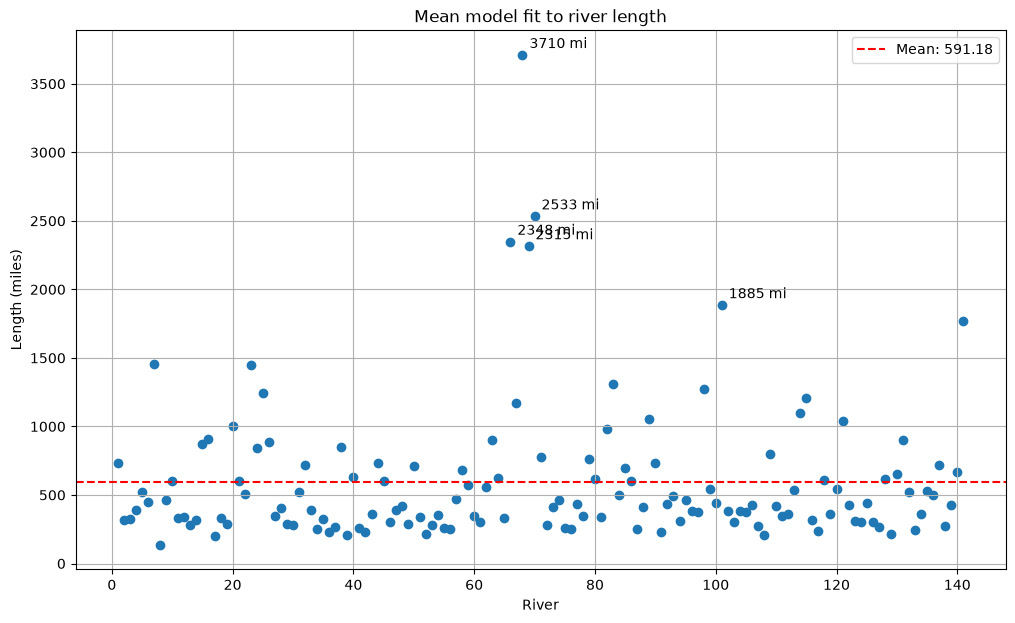

In [93]:
#3. Produce a graph showing your model of the mean fit to the data. 
# Hint: create an index variable to identify each river and use a 

# create index for the x-axis
river_index = range(1, len(df["length"])+1)

# size of the plot figure
plt.figure(figsize=(12, 7))

# scatter plot
plt.scatter(x=river_index, y=df["length"])
# sns.scatterplot(data=df, x=river_index, y="length")

# add the mean model
plt.axhline(y=mean_length, linestyle="--", label=f"Mean: {mean_length:.2f}", color="red")

plt.grid(visible=True)

plt.xlabel("River")
plt.ylabel("Length (miles)")
plt.title("Mean model fit to river length")

#display label
plt.legend()

# highlight the 5 largest observations (potential outliers)
largest = df.nlargest(n=5, columns="length")

for index, row in largest.iterrows():
    plt.annotate(
        f"{row["length"]} mi",
        (index+1, row["length"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

### Step 4: Calculate the Standard Error of the Mean Length
$$
SE_{\bar{x}} = \frac{s}{\sqrt{n}}
$$
where:

- $s$ = sample standard deviation
- $n$ = sample size

In [94]:
s = df["length"].std() # uses ddof=1 by default, which means it calculates sample std rather than population std, i.e the denominator is (n-1)
n = len(df["length"])
se = s/np.sqrt(n)

print(f"sample standard deviation: {s:.2f}, sample size: {n}, standard error: {se:.2f}")

sample standard deviation: 493.87, sample size: 141, standard error: 41.59


### Step 5: Calculate a 95% confidence interval for the mean length.

A 95% confidence interval for the population mean is calculated as:

$$
\bar{x} \pm t^* * SE_{\bar{x}}
$$

where:

- $\bar{x}$ = sample mean
- $t^*$ = critical value from the $t$-distribution
- $SE_{\bar{x}}$ = standard error of the mean
- $df = n - 1$ = degrees of freedom

For a 95% confidence interval:

$$
t^* = t_{0.975,\;n-1}
$$

refer to the t-distribution table for extracting the value https://www.sjsu.edu/faculty/gerstman/StatPrimer/t-table.pdf (just for understanding), python and R do the work

The confidence interval gives a range of plausible values for the **population mean** based on the sample.

For the 141 rivers:

$$
df = 141 - 1 = 140
$$

and therefore:

$$
t^* = t_{0.975,140} \approx 1.977
$$

In [95]:
# Critical t-value
t_critical95 = stats.t.ppf(0.975, df=n - 1)
print(f"critical t-value for 95% confidence: {t_critical95:.3f}")
# 0.975 = cumulative probability for a 95% two-sided CI
# n - 1 = degrees of freedom

# confidence interval
lower_bound95 = mean_length - t_critical95 * se
upper_bound95 = mean_length + t_critical95 * se

print(f"95% CI: ({lower_bound95:0.2f}, {upper_bound95:0.2f})")

critical t-value for 95% confidence: 1.977
95% CI: (508.96, 673.41)


### Step 6: Calculate a 90% confidence interval for the mean length. 

A 90% confidence interval for the population mean is calculated as:

$$
\bar{x} \pm t^* * SE_{\bar{x}}
$$

For a 90% confidence interval:

$$
t^* = t_{0.95,\;n-1}
$$


The confidence interval gives a range of plausible values for the **population mean** based on the sample.

For the 141 rivers:

$$
df = 141 - 1 = 140
$$

and therefore:

$$
t^* = t_{0.95,140} \approx 1.656
$$

In [96]:
# Critical t-value
t_critical90 = stats.t.ppf(0.95, df=n - 1)
print(f"critical t-value for 90% confidence: {t_critical90:.3f}")
# 0.95 = cumulative probability for a 90% two-sided CI
# n - 1 = degrees of freedom

# confidence interval
lower_bound90 = mean_length - t_critical90 * se
upper_bound90 = mean_length + t_critical90 * se

print(f"90% CI: ({lower_bound90:0.2f}, {upper_bound90:0.2f})")

critical t-value for 90% confidence: 1.656
90% CI: (522.32, 660.05)


-----------


### Reflection:
##### 1. do any observations look like potential outliers?  
The calculated mean is 591.18 miles.  
from the scatter plot at **Step 3**, there are potential outliers that fall far from the mean.  
The most noticeable is the river with length of 3,710 miles, and a couple of other values at 2533, 2348, and 2315 miles, which look substantially separated from the majority of the observations.  
There are also several rivers of long length, above 1500 miles.  
Those extreme values may have substantial influence on the sample mean of 591.18 miles.  

I highlited the largest 5 values on the scatter plot.


##### 2. Which confidence interval is wider, 95% or 90%? What does this suggest?  
from steps 5, and 6:  
95% CI: (508.96, 673.41)  
90% CI: (522.32, 660.05)  
so the 95% CI is wider.  
because:  $ t^*_{95\%}\approx1.977 $ while $ t^*_{90\%}\approx1.656 $

Therefore:   $ \boxed{95\% \text{ CI is wider because }t^*_{95\%}>t^*_{90\%}} $

And since:   $ CI=\bar{x}\pm t^*SE $

a larger critical value ($t^*$) means you move farther from the mean in both directions.

**In short**: the 95% CI is wider than the 90% CI, and this suggests that greater confidence in capturing the in measuring the population mean requires a wider range of plausible values  


##### 3. Would you get different answers to the questions above with another random sample of the same size?
Yes, another sample could have different observations, and hence could produce different results.  Therefore, the sample mean, amount of variation, standard error of the mean, and the bounds of the confidence interval could all change from one sample to another. However, repeated random samples from the same population are expected to produce estimates (bounds for the mean) that vary around the population parameter.  

For example, for 95% confidence level, repeating the procedure for 100 different samples of the same size could produce 100 different Confidence intervals, approximately 95 of them are expected to contain the value of the population parameter (the mean in our case)  


##### 4. Is it possible to have the same mean but a different amount of error with another random sample of the same size?  
Yes, two random samples of the same size can have the same mean, but different spread (different values could result in different amount of variation) resulting in different standard deviation.  
Since the standard error depends on the standard deviation (having n the same for both samples) then the standard error can be different.  
The sample with bigger variation will produce bigger standard error, hence wider CI, meaning less precision in the population parameter estimate